<a href="https://colab.research.google.com/github/Abrewst/ML-repo/blob/main/assignment1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
upload = files.upload()


Saving D3.csv to D3.csv


In [2]:
import pandas as pd

In [3]:
import io
df = pd.read_csv(io.BytesIO(upload['D3.csv']))

In [4]:
df.head()

,X1,X2,X3,Y
0,0.000000,3.440000,0.440000,4.387545
1,0.040404,0.134949,0.888485,2.679650
2,0.080808,0.829899,1.336970,2.968490
3,0.121212,1.524848,1.785455,3.254065
4,0.161616,2.219798,2.233939,3.536375


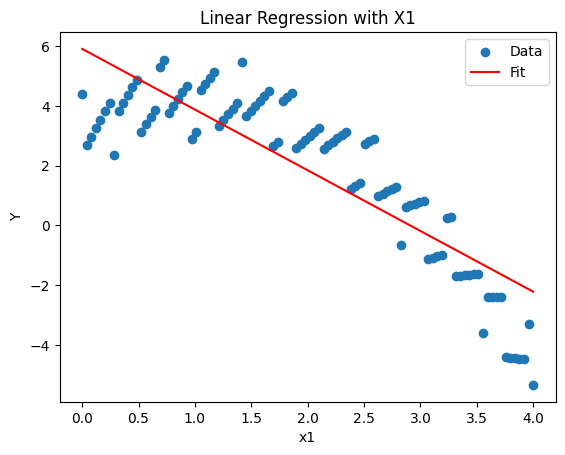

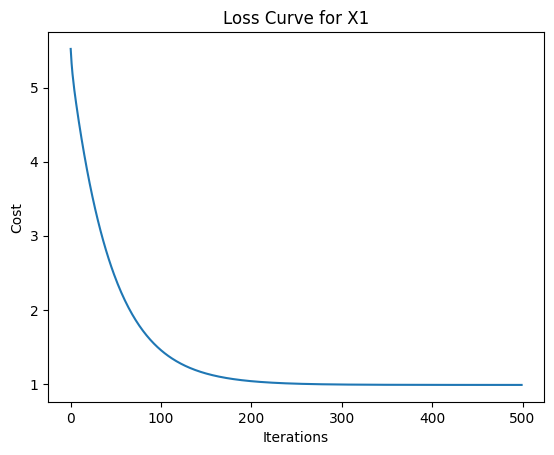

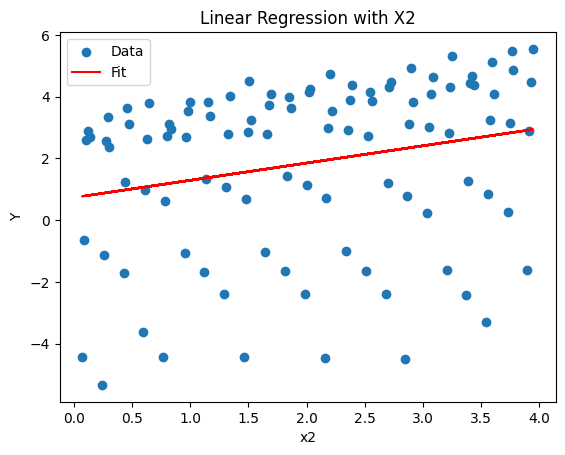

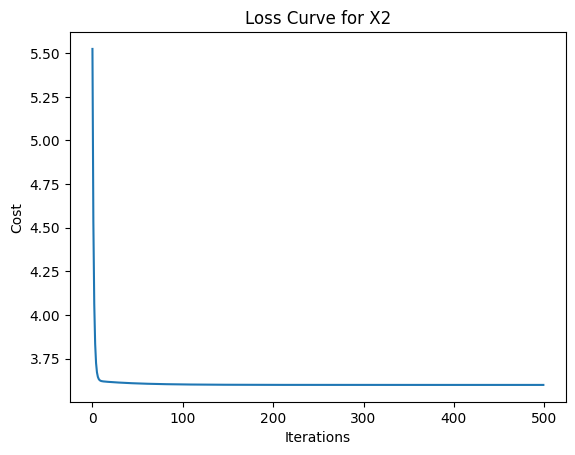

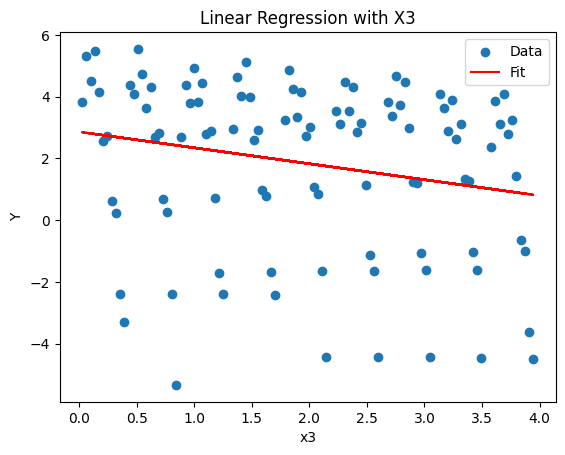

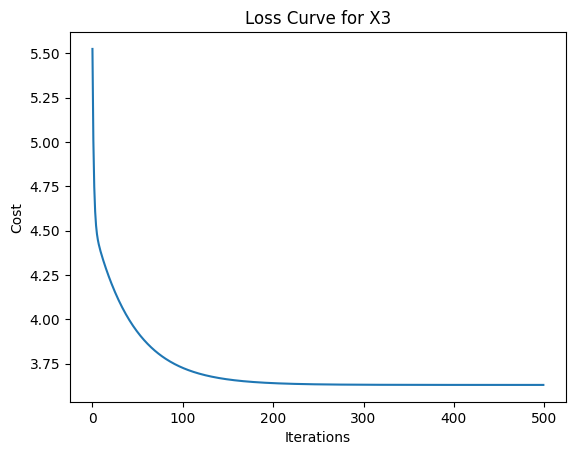

In [7]:
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("D3.csv", skiprows=1, header=None)
X = data.iloc[:, 0:3].values.astype(float)
Y = data.iloc[:, 3].values.astype(float)
m = len(Y)

def gradient_descent(x, y, alpha=0.01, iterations=1000):
    theta0, theta1 = 0, 0
    cost_history = []

    for _ in range(iterations):
        h = theta0 + theta1 * x
        error = h - y
        cost = (1/(2*m)) * np.sum(error**2)
        cost_history.append(cost)


        theta0 -= alpha * (1/m) * np.sum(error)
        theta1 -= alpha * (1/m) * np.sum(error * x)

    return theta0, theta1, cost_history


results = {}
for i in range(3):
    x = X[:, i]
    t0, t1, cost_hist = gradient_descent(x, Y, alpha=0.05, iterations=500)
    results[f"x{i+1}"] = (t0, t1, cost_hist)


    plt.scatter(x, Y, label="Data")
    plt.plot(x, t0 + t1*x, color="red", label="Fit")
    plt.title(f"Linear Regression with X{i+1}")
    plt.xlabel(f"x{i+1}")
    plt.ylabel("Y")
    plt.legend()
    plt.show()


    plt.plot(cost_hist)
    plt.title(f"Loss Curve for X{i+1}")
    plt.xlabel("Iterations")
    plt.ylabel("Cost")
    plt.show()

Final theta: [ 5.27907019 -1.99876124  0.53836289 -0.26045736]
Model: Y = 5.2791 + -1.9988*X1 + 0.5384*X2 + -0.2605*X3


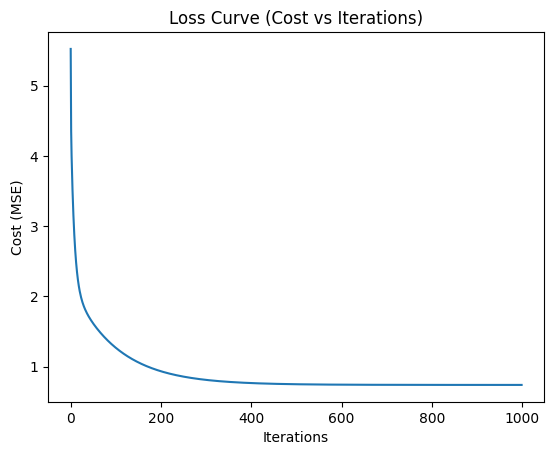

Prediction for (1,1,1): 3.5582144859075004
Prediction for (2,0,4): 0.23971826711406008
Prediction for (3,2,1): 0.09905490184029686


In [9]:
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("D3.csv", header=None, skiprows=1)
X = data.iloc[:, 0:3].values.astype(float)
Y = data.iloc[:, 3].values.astype(float)
m = len(Y)


X_b = np.c_[np.ones((m, 1)), X]

def gradient_descent(X, y, alpha=0.05, iterations=1000):
    m, n = X.shape
    theta = np.zeros(n)
    cost_history = []

    for _ in range(iterations):
        h = X.dot(theta)
        error = h - y
        cost = (1/(2*m)) * np.sum(error**2)
        cost_history.append(cost)

        gradient = (1/m) * X.T.dot(error)
        theta -= alpha * gradient

    return theta, cost_history


theta, cost_hist = gradient_descent(X_b, Y, alpha=0.05, iterations=1000)

print("Final theta:", theta)


print(f"Model: Y = {theta[0]:.4f} + {theta[1]:.4f}*X1 + {theta[2]:.4f}*X2 + {theta[3]:.4f}*X3")


plt.plot(cost_hist)
plt.title("Loss Curve (Cost vs Iterations)")
plt.xlabel("Iterations")
plt.ylabel("Cost (MSE)")
plt.show()


def predict(new_X):
    new_X_b = np.insert(new_X, 0, 1)  # add bias term
    return new_X_b.dot(theta)

print("Prediction for (1,1,1):", predict(np.array([1,1,1])))
print("Prediction for (2,0,4):", predict(np.array([2,0,4])))
print("Prediction for (3,2,1):", predict(np.array([3,2,1])))

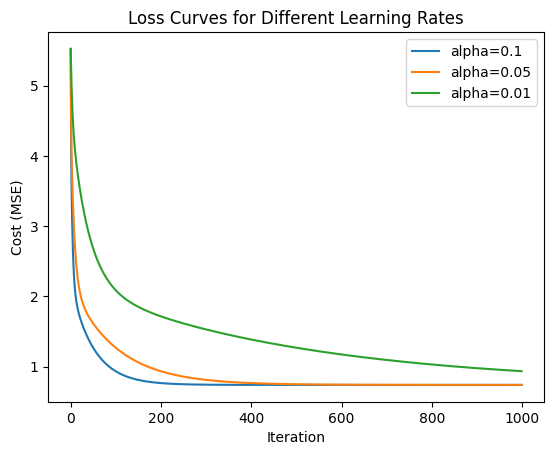

Best learning rate: 0.1
Final parameters (theta): [ 5.31393577 -2.00368658  0.53260157 -0.26556795]
Model: Y = 5.3139 + -2.0037*X1 + 0.5326*X2 + -0.2656*X3


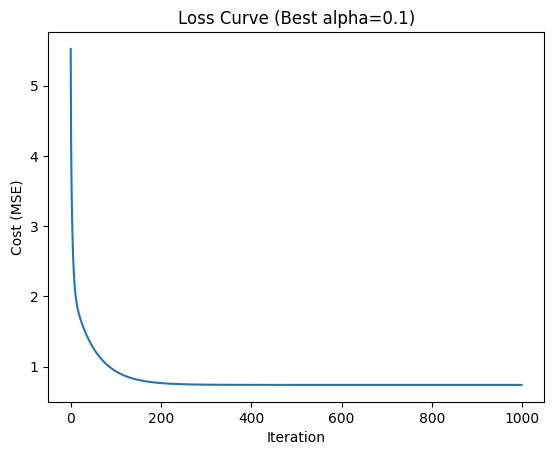

Prediction for (1,1,1): 3.5772828177319926
Prediction for (2,0,4): 0.24429082475948705
Prediction for (3,2,1): 0.10251123321230132


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


data = pd.read_csv("D3.csv", header=None, skiprows=1)
X = data.iloc[:, 0:3].values.astype(float)
Y = data.iloc[:, 3].values.astype(float)
m = len(Y)


X_b = np.c_[np.ones((m, 1)), X]


def compute_cost(X, y, theta):
    m = len(y)
    predictions = X.dot(theta)
    cost = (1/(2*m)) * np.sum((predictions - y)**2)
    return cost


def gradient_descent(X, y, alpha=0.05, iterations=1000):
    m, n = X.shape
    theta = np.zeros(n)
    cost_history = []

    for _ in range(iterations):
        predictions = X.dot(theta)
        error = predictions - y
        cost = compute_cost(X, y, theta)
        cost_history.append(cost)

        gradient = (1/m) * X.T.dot(error)
        theta -= alpha * gradient

    return theta, cost_history

learning_rates = [0.1, 0.05, 0.01]
results = {}

for alpha in learning_rates:
    theta, cost_hist = gradient_descent(X_b, Y, alpha=alpha, iterations=1000)
    results[alpha] = (theta, cost_hist)


    plt.plot(cost_hist, label=f"alpha={alpha}")

plt.title("Loss Curves for Different Learning Rates")
plt.xlabel("Iteration")
plt.ylabel("Cost (MSE)")
plt.legend()
plt.show()


best_alpha = min(results, key=lambda a: results[a][1][-1])
best_theta, best_cost_hist = results[best_alpha]

print(f"Best learning rate: {best_alpha}")
print("Final parameters (theta):", best_theta)
print(f"Model: Y = {best_theta[0]:.4f} + {best_theta[1]:.4f}*X1 + {best_theta[2]:.4f}*X2 + {best_theta[3]:.4f}*X3")


plt.plot(best_cost_hist)
plt.title(f"Loss Curve (Best alpha={best_alpha})")
plt.xlabel("Iteration")
plt.ylabel("Cost (MSE)")
plt.show()


def predict(new_X):
    new_X_b = np.insert(new_X, 0, 1)
    return new_X_b.dot(best_theta)


print("Prediction for (1,1,1):", predict(np.array([1,1,1])))
print("Prediction for (2,0,4):", predict(np.array([2,0,4])))
print("Prediction for (3,2,1):", predict(np.array([3,2,1])))